<a href="https://colab.research.google.com/github/edmilsonguimaraes88-cyberpreto/Projeto_FoundMysoz/blob/main/C%C3%B3pia_de_Snippets_Importing_libraries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Cêfrom google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install deepface

In [ ]:
!pip install face_recognition

/content/eu.jpg

/content/sample_data/base_famosos

Configurando os motores da FoundMysoz... por favor, aguarde.
Bibliotecas já instaladas!
--- Bem-vindo à FoundMysoz ---
Analisando sua foto de entrada: /content/eu.jpg
Buscando sósias na pasta: /content/sample_data/base_famosos/
✓ Encontrei 9 fotos de possíveis sósias para comparar. Iniciando análise...
26-03-15 09:11:57 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:05<00:00, 114MB/s]



--- FIM DA ANÁLISE ---

🏆 RESULTADO FINAL FOUNDMYSOZ 🏆
O seu maior sósia encontrado é: Edgar!
Nível de semelhança estimado: 77.3%


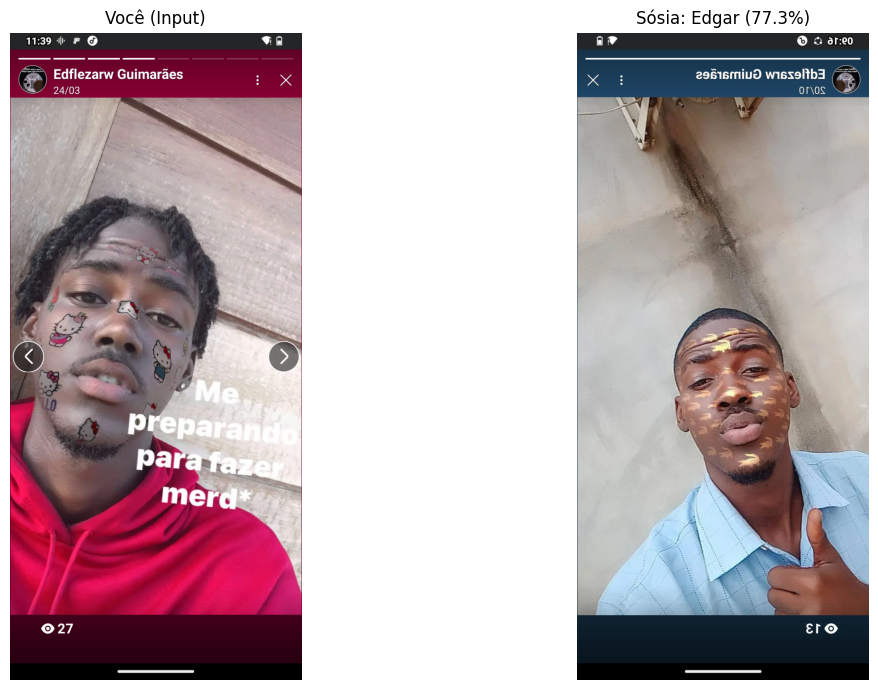


Ranking Completo (Top 5):
     Sósia  Semelhança
     Edgar       77.30
     Veigh       66.30
    Orochi       52.78
Jay morant       34.73
       Fly       12.25


In [ ]:
# ==============================================================================
# FOUNDMYSOZ - PROTÓTIPO DE BUSCA DE SÓSIAS (ATUALIZADO)
# ==============================================================================

# 1. Instalação das bibliotecas (Rode apenas uma vez, se necessário)
print("Configurando os motores da FoundMysoz... por favor, aguarde.")
try:
    import deepface
    import cv2
    import matplotlib.pyplot as plt
    import pandas as pd
    import glob
    import os
    print("Bibliotecas já instaladas!")
except ImportError:
    print("Instalando bibliotecas necessárias...")
    !pip install deepface opencv-python matplotlib pandas -q
    import deepface
    import cv2
    import matplotlib.pyplot as plt
    import pandas as pd
    import glob
    import os
    print("Instalação concluída com sucesso!")

# ==============================================================================
# 2. CONFIGURAÇÕES DE ENTRADA (MUITO IMPORTANTE!)
# ==============================================================================

# ONDE COLOCAR SUA FOTO DE ENTRADA:
# No menu lateral esquerdo do Colab (ícone de pasta), faça o upload da SUA foto
# e renomeie o arquivo para 'eu.jpg'. Ele deve ficar solto na pasta principal.
SUA_FOTO = '/content/eu.jpg'

# ONDE ESTÃO AS FOTOS DOS FAMOSOS (BASE DE DADOS):
# Você me confirmou este caminho. Certifique-se de que a pasta 'base_famosos'
# está exatamente dentro de 'sample_data' no menu lateral.
PASTA_FAMOSOS = '/content/sample_data/base_famosos/'

print(f"--- Bem-vindo à FoundMysoz ---")
print(f"Analisando sua foto de entrada: {SUA_FOTO}")
print(f"Buscando sósias na pasta: {PASTA_FAMOSOS}")

# ==============================================================================
# 3. LÓGICA DE COMPARAÇÃO (EMBEDDINGS)
# ==============================================================================
resultados = []

# Verificação de segurança: sua foto existe?
if not os.path.exists(SUA_FOTO):
    print("❌ ERRO CRÍTICO: Não achei o arquivo 'eu.jpg'. Por favor, faça o upload no menu lateral (pasta principal).")
# Verificação de segurança: a pasta dos famosos existe?
elif not os.path.exists(PASTA_FAMOSOS):
    print(f"❌ ERRO CRÍTICO: Não encontrei a pasta '{PASTA_FAMOSOS}'. Verifique se o caminho está correto.")
else:
    # 3.1. Busca por todas as fotos na pasta (jpg, jpeg, png, maiúsculas e minúsculas)
    extensoes = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    lista_todos_arquivos = []
    for extensao in extensoes:
        lista_todos_arquivos.extend(glob.glob(os.path.join(PASTA_FAMOSOS, extensao)))

    # 3.2. Filtra para remover sua própria foto da comparação (caso ela esteja lá por engano)
    lista_famosos = [f for f in lista_todos_arquivos if 'eu.jpg' not in f]

    total_famosos = len(lista_famosos)
    print(f"✓ Encontrei {total_famosos} fotos de possíveis sósias para comparar. Iniciando análise...")

    if total_famosos == 0:
        print("⚠️ AVISO: A pasta de famosos foi encontrada, mas não contém fotos com as extensões suportadas (.jpg, .jpeg, .png).")
    else:
        # 3.3. Loop para comparar sua foto com cada famoso
        for i, caminho_famoso in enumerate(lista_famosos):
            nome_famoso = os.path.basename(caminho_famoso).replace('.jpg', '').replace('.jpeg', '').replace('.png', '').replace('.JPG', '').replace('.JPEG', '').replace('.PNG', '')

            # Mostra progresso simples
            print(f"[{i+1}/{total_famosos}] Analisando {nome_famoso}...", end='\r')

            try:
                # Usando 'VGG-Face' que é excelente para características faciais
                # 'enforce_detection=False' para não quebrar se o rosto não for perfeitamente detectado
                analise = DeepFace.verify(img1_path = SUA_FOTO,
                                         img2_path = caminho_famoso,
                                         model_name = 'VGG-Face',
                                         enforce_detection = False)

                distancia = analise['distance']
                # Quanto menor a distância, maior a semelhança (calculando % aproximada)
                # Nota: Este cálculo de % é uma aproximação para exibição, não uma métrica linear perfeita.
                score = round((1 - distancia) * 100, 2)

                resultados.append({
                    'Sósia': nome_famoso,
                    'Semelhança': score,
                    'Distância': distancia, # Guardamos a distância real para ordenação mais precisa
                    'Caminho': caminho_famoso
                })

            except Exception as e:
                # Em caso de erro em uma foto específica, pula para a próxima
                print(f"\n! Erro ao analisar foto de {nome_famoso}: {e}")

# ==============================================================================
# 4. EXIBIÇÃO DO VENCEDOR DA FOUNDMYSOZ
# ==============================================================================
print("\n--- FIM DA ANÁLISE ---")

if resultados:
    # Cria um DataFrame para facilitar a ordenação e exibição
    df = pd.DataFrame(resultados)
    # Ordenar por MENOR distância (que significa maior semelhança)
    df_ordenado = df.sort_values(by='Distância', ascending=True)

    vencedor = df_ordenado.iloc[0]

    print(f"\n🏆 RESULTADO FINAL FOUNDMYSOZ 🏆")
    print(f"O seu maior sósia encontrado é: {vencedor['Sósia']}!")
    print(f"Nível de semelhança estimado: {vencedor['Semelhança']}%")

    # Mostrar as fotos lado a lado para validação visual
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))

    # 4.1. Sua foto de entrada
    img_eu = cv2.cvtColor(cv2.imread(SUA_FOTO), cv2.COLOR_BGR2RGB)
    ax[0].imshow(img_eu)
    ax[0].set_title("Você (Input)")
    ax[0].axis('off')

    # 4.2. Foto do sósia vencedor
    img_sosia = cv2.cvtColor(cv2.imread(vencedor['Caminho']), cv2.COLOR_BGR2RGB)
    ax[1].imshow(img_sosia)
    ax[1].set_title(f"Sósia: {vencedor['Sósia']} ({vencedor['Semelhança']}%)")
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Exibe o ranking completo para curiosidade
    print("\nRanking Completo (Top 5):")
    # Mostra apenas as colunas relevantes e as 5 primeiras linhas
    print(df_ordenado[['Sósia', 'Semelhança']].head(5).to_string(index=False))

else:
    if total_famosos > 0:
        print("Infelizmente, ocorreu um erro ao analisar as fotos da base de dados e não pudemos encontrar um sósia.")